In [1]:
import xarray as xr
import numpy as np

import sys
sys.path.append('./subroutine')
from rfft2 import rfft2, irfft2
from isospec_rfft import isospec_rfft
from rel_err import rel_err

import matplotlib.pyplot as plt
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1 import ImageGrid
import cmocean.cm as cmo
plt.style.use('/mnt/c/Ryan_Data/Python_Tool/ryan_mplstyle.mplstyle')

In [ ]:
# Everything here is dimensional

# dx is in m, get dimensional wavenumber
def kxky(pressure__,dx):
    kx = np.fft.rfftfreq(pressure__.shape[0],d=dx)*(2*np.pi)
    ky = np.fft.fftfreq (pressure__.shape[0],d=dx)*(2*np.pi)

    return kx,ky

################################
def U_GB__func(pressure__,dx,f):
    kx,ky = kxky(pressure__,dx)
    
    pressure_y__ = (pressure__.T*1j*ky).T

    return -pressure_y__ / f

def V_GB__func(pressure__,dx,eps):
    kx,ky = kxky(pressure__,dx)
    
    pressure_x__ = pressure__*1j*kx
    
    return pressure_x__ / f

################################

def zeta_fuv__func(pressure__,dx,f):
    kx,ky = kxky(pressure__,dx)

    Vx__ =  V_GB__func(pressure__,dx,f) *1j*kx
    Uy__ = (U_GB__func(pressure__,dx,f) .T*1j*ky).T
    
    return Vx__-Uy__

def strain_fuv__func(pressure__,dx,f):
    kx,ky = kxky(pressure__,dx)

    Ux = irfft2( U_GB__func(pressure__,dx,f)*1j*kx)
    Vx = irfft2( V_GB__func(pressure__,dx,f)*1j*kx)
    Uy = irfft2( (U_GB__func(pressure__,dx,f).T*1j*ky).T)
    Vy = irfft2( (V_GB__func(pressure__,dx,f).T*1j*ky).T)

    strain_fuv = np.sqrt(  (Ux-Vy)**2+(Vx+Uy)**2  )
    
    return rfft2(strain_fuv)

In [3]:
ds_truth = xr.open_dataset("data/data_channel/processed/truth.nc")
ds_lpfilter = xr.open_dataset("data/data_channel/processed/Fourier_lpfilter.nc")

In [4]:
ds_lpfilter

<xarray.Dataset> Size: 4MB
Dimensions:         (x: 400, y: 400, kx: 400, ky: 201)
Coordinates:
    x               (x, y) float32 640kB ...
    y               (x, y) float32 640kB ...
Dimensions without coordinates: kx, ky
Data variables:
    lowpass_filter  (kx, ky) float64 643kB ...
    press_lpfilter  (x, y) float32 640kB ...
    zeta_windowed   (x, y) float64 1MB ...
    cut_id          int64 8B ...

In [5]:
x = ds_truth.x.values
y = ds_truth.y.values

f = ds_truth.f.values

press_lpfilter__ = rfft2(ds_lpfilter.press_lpfilter.values)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [ ]:
dx = 1000 # in meters

U_GeoBal__ = U_GB__func(press_lpfilter__,dx,f)
U_GeoBal = irfft2(U_GeoBal__)

V_GeoBal__ = V_GB__func(press_lpfilter__,dx,f)
V_GeoBal = irfft2(V_GeoBal__)

zeta_GeoBal__ = zeta_fuv__func(press_lpfilter__,dx,f)/f
zeta_GeoBal = irfft2(zeta_GeoBal__)

strain_GeoBal__ = strain_fuv__func(press_lpfilter__,dx,f)/np.abs(f)
strain_GeoBal = irfft2(strain_GeoBal__)

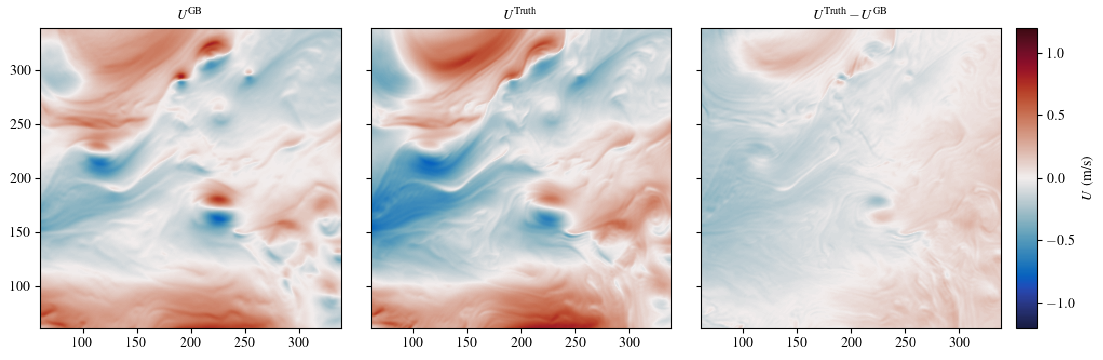

In [ ]:
# Only plot the meaningful part (flat part of the window)
xl = ds_lpfilter.cut_id.values; xh = -ds_lpfilter.cut_id.values
yl = ds_lpfilter.cut_id.values; yh = -ds_lpfilter.cut_id.values

fig = plt.figure(figsize=(9*1.5, 2.6*1.5))

grid = ImageGrid(fig, 111,          # as in plt.subplot(111)
                 nrows_ncols=(1,3),
                 axes_pad=0.3,
                 share_all=True,
                 cbar_location="right",
                 cbar_mode="single",
                 cbar_size="7%",
                 cbar_pad=0.15,
                 )
cmax = 1.2

U_GeoBal_crop = U_GeoBal[xl:xh,yl:yh]
U_truth_demean_crop = ds_truth.U_surface[xl:xh,yl:yh]-np.mean(ds_truth.U_surface[xl:xh,yl:yh])

im0 = grid[0].pcolor(x[xl:xh,yl:yh]/1000,y[xl:xh,yl:yh]/1000,U_GeoBal_crop, cmap=cmo.balance, vmin=-cmax, vmax=cmax)
grid[0].set_title(r"$U^\mathrm{GB}$")
im1 = grid[1].pcolor(x[xl:xh,yl:yh]/1000,y[xl:xh,yl:yh]/1000,U_truth_demean_crop, cmap=cmo.balance, vmin=-cmax, vmax=cmax)
grid[1].set_title(r"$U^\mathrm{Truth}$")
im2 = grid[2].pcolor(x[xl:xh,yl:yh]/1000,y[xl:xh,yl:yh]/1000,(U_truth_demean_crop-U_GeoBal_crop), cmap=cmo.balance, vmin=-cmax, vmax=cmax)
grid[2].set_title(r"$U^\mathrm{Truth}-U^\mathrm{GB}$")

cbar = grid[2].cax.colorbar(im2)
cbar.set_label("$U$ (m/s)")

plt.show()

# Did not detrend truth U and V!!!

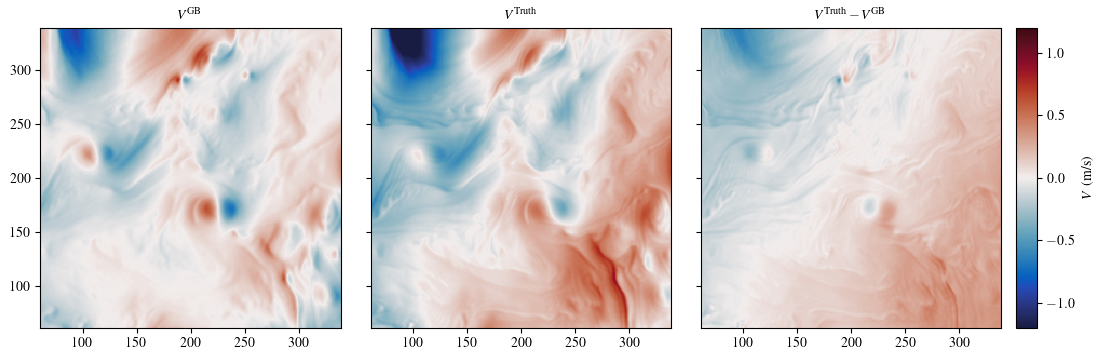

In [8]:
xl = ds_lpfilter.cut_id.values; xh = -ds_lpfilter.cut_id.values
yl = ds_lpfilter.cut_id.values; yh = -ds_lpfilter.cut_id.values

fig = plt.figure(figsize=(9*1.5, 2.6*1.5))

grid = ImageGrid(fig, 111,          # as in plt.subplot(111)
                 nrows_ncols=(1,3),
                 axes_pad=0.3,
                 share_all=True,
                 cbar_location="right",
                 cbar_mode="single",
                 cbar_size="7%",
                 cbar_pad=0.15,
                 )
cmax = 1.2

V_GeoBal_crop = V_GeoBal[xl:xh,yl:yh]
V_truth_demean_crop = ds_truth.V_surface[xl:xh,yl:yh]-np.mean(ds_truth.V_surface[xl:xh,yl:yh])

im0 = grid[0].pcolor(x[xl:xh,yl:yh]/1000,y[xl:xh,yl:yh]/1000,V_GeoBal_crop, cmap=cmo.balance, vmin=-cmax, vmax=cmax)
grid[0].set_title(r"$V^\mathrm{GB}$")
im1 = grid[1].pcolor(x[xl:xh,yl:yh]/1000,y[xl:xh,yl:yh]/1000,V_truth_demean_crop, cmap=cmo.balance, vmin=-cmax, vmax=cmax)
grid[1].set_title(r"$V^\mathrm{Truth}$")
im2 = grid[2].pcolor(x[xl:xh,yl:yh]/1000,y[xl:xh,yl:yh]/1000,(V_truth_demean_crop-V_GeoBal_crop), cmap=cmo.balance, vmin=-cmax, vmax=cmax)
grid[2].set_title(r"$V^\mathrm{Truth}-V^\mathrm{GB}$")

cbar = grid[2].cax.colorbar(im2)
cbar.set_label("$V$ (m/s)")

plt.show()

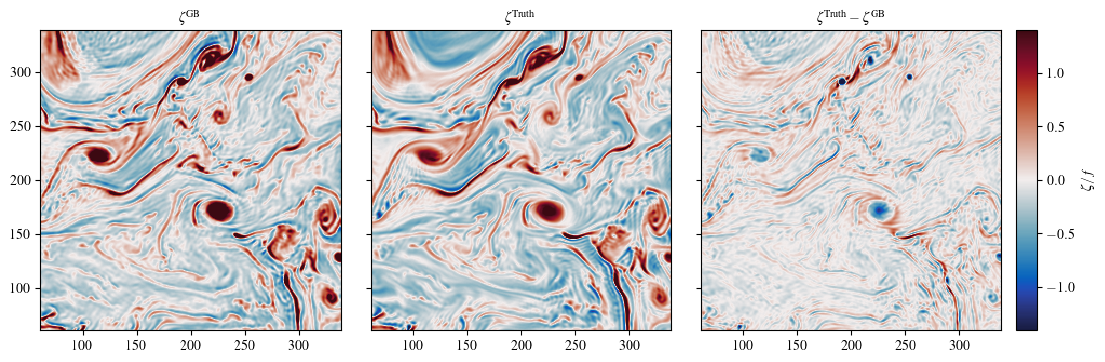

0.5057197


In [ ]:
xl = ds_lpfilter.cut_id.values; xh = -ds_lpfilter.cut_id.values
yl = ds_lpfilter.cut_id.values; yh = -ds_lpfilter.cut_id.values

fig = plt.figure(figsize=(9*1.5, 2.6*1.5))

grid = ImageGrid(fig, 111,          # as in plt.subplot(111)
                 nrows_ncols=(1,3),
                 axes_pad=0.3,
                 share_all=True,
                 cbar_location="right",
                 cbar_mode="single",
                 cbar_size="7%",
                 cbar_pad=0.15,
                 )
cmax = 1.4

zeta_GeoBal_crop = zeta_GeoBal[xl:xh,yl:yh]
zeta_truth_crop = ds_truth.zeta_surface[xl:xh,yl:yh].values

im0 = grid[0].pcolor(x[xl:xh,yl:yh]/1000,y[xl:xh,yl:yh]/1000,zeta_GeoBal_crop, cmap=cmo.balance, vmin=-cmax, vmax=cmax)
grid[0].set_title(r"$\zeta^\mathrm{GB}$")
im1 = grid[1].pcolor(x[xl:xh,yl:yh]/1000,y[xl:xh,yl:yh]/1000,zeta_truth_crop, cmap=cmo.balance, vmin=-cmax, vmax=cmax)
grid[1].set_title(r"$\zeta^\mathrm{Truth}$")
im2 = grid[2].pcolor(x[xl:xh,yl:yh]/1000,y[xl:xh,yl:yh]/1000,(zeta_truth_crop-zeta_GeoBal_crop), cmap=cmo.balance, vmin=-cmax, vmax=cmax)
grid[2].set_title(r"$\zeta^\mathrm{Truth}-\zeta^\mathrm{GB}$")

cbar = grid[2].cax.colorbar(im2)
cbar.set_label("$\zeta/f$")

plt.show()

print(rel_err(zeta_truth_crop,zeta_GeoBal_crop))
# Truth zeta is detrended

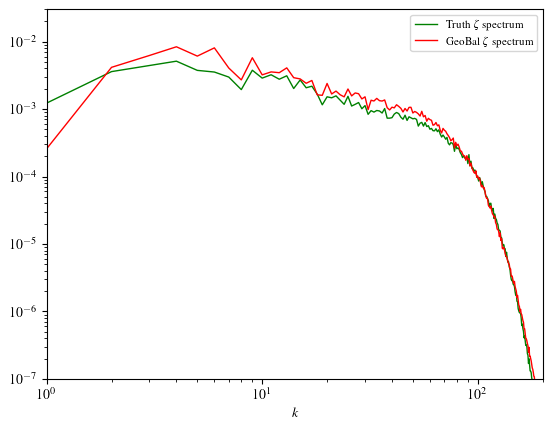

In [10]:
# k_cpkm = np.arange(0,Eta_spec.size,1.)*(k_domain_factor)

zeta_truth_windowed__ = rfft2(ds_lpfilter.zeta_windowed.values)
zeta_GeoBal__ = rfft2(zeta_GeoBal)

zeta_truth_spec = isospec_rfft( np.abs(zeta_truth_windowed__)**2 )
zeta_GeoBal_spec = isospec_rfft( np.abs(zeta_GeoBal__)**2 )

err_GeoBal_spec = isospec_rfft( np.abs(zeta_GeoBal__-zeta_truth_windowed__)**2 )

plt.loglog(zeta_truth_spec,'g',label="Truth $\zeta$ spectrum")
plt.loglog(zeta_GeoBal_spec,'r',label="GeoBal $\zeta$ spectrum")

# plt.loglog(k_ndim,errSQGp1_spec,'b--')
# plt.loglog(k_ndim,errbay_spec,'r--')

# plt.axvline(1/33*k_fac,color='k')

plt.ylim([1e-7,0.03])
plt.xlabel("$k$ ")
plt.legend()

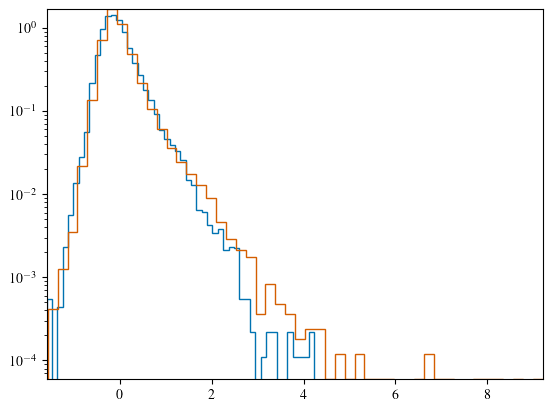

In [11]:
plt.hist(zeta_truth_crop.ravel(), log=True, density=True, bins=50, histtype='step')
plt.hist(zeta_GeoBal_crop.ravel(), log=True, density=True, bins=50, histtype='step')

plt.show()

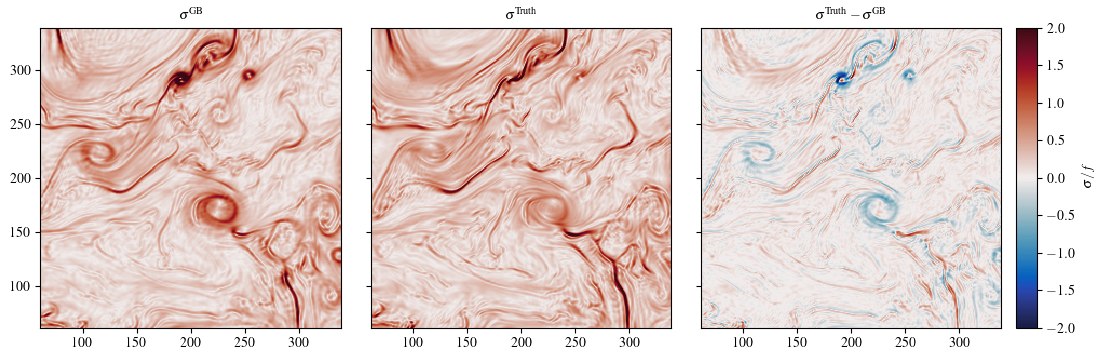

<xarray.DataArray 'strain_surface' ()> Size: 8B
array(0.68555456)


In [12]:
xl = ds_lpfilter.cut_id.values; xh = -ds_lpfilter.cut_id.values
yl = ds_lpfilter.cut_id.values; yh = -ds_lpfilter.cut_id.values

fig = plt.figure(figsize=(9*1.5, 2.6*1.5))

grid = ImageGrid(fig, 111,          # as in plt.subplot(111)
                 nrows_ncols=(1,3),
                 axes_pad=0.3,
                 share_all=True,
                 cbar_location="right",
                 cbar_mode="single",
                 cbar_size="7%",
                 cbar_pad=0.15,
                 )
cmax = 2

strain_GeoBal_crop = strain_GeoBal[xl:xh,yl:yh]
strain_truth_crop = ds_truth.strain_surface[xl:xh,yl:yh]

im0 = grid[0].pcolor(x[xl:xh,yl:yh]/1000,y[xl:xh,yl:yh]/1000,strain_GeoBal_crop, cmap=cmo.amp, vmin=0, vmax=cmax)
grid[0].set_title(r"$\sigma^\mathrm{GB}$")
im1 = grid[1].pcolor(x[xl:xh,yl:yh]/1000,y[xl:xh,yl:yh]/1000,strain_truth_crop, cmap=cmo.amp, vmin=0, vmax=cmax)
grid[1].set_title(r"$\sigma^\mathrm{Truth}$")
im2 = grid[2].pcolor(x[xl:xh,yl:yh]/1000,y[xl:xh,yl:yh]/1000,(strain_truth_crop-strain_GeoBal_crop), cmap=cmo.balance, vmin=-cmax, vmax=cmax)
grid[2].set_title(r"$\sigma^\mathrm{Truth}-\sigma^\mathrm{GB}$")

cbar = grid[2].cax.colorbar(im2)
cbar.set_label("$\sigma/f$")

plt.show()

print(rel_err(strain_truth_crop,strain_GeoBal_crop))

In [13]:
d_save = xr.Dataset(
    
    # dims=["x", "y"],
    coords=dict(
        x=(["x", "y"], ds_truth.x.values),
        y=(["x", "y"], ds_truth.y.values),
    ),
)

d_save["zeta_GeoBal"]=(["x", "y"],  zeta_GeoBal)
d_save["strain_GeoBal"]=(["x", "y"],  strain_GeoBal)

In [14]:
d_save

<xarray.Dataset> Size: 3MB
Dimensions:        (x: 400, y: 400)
Coordinates:
    x              (x, y) float32 640kB 500.0 1.5e+03 ... 3.985e+05 3.995e+05
    y              (x, y) float32 640kB 500.0 500.0 ... 3.995e+05 3.995e+05
Data variables:
    zeta_GeoBal    (x, y) float32 640kB -3.538e-06 -0.0002326 ... 1.153e-06
    strain_GeoBal  (x, y) float32 640kB 0.0001345 0.000213 ... 0.0001613

In [15]:
d_save.to_netcdf('data/data_channel/processed/Geo_Balanced.nc')